In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

# Project root
PROJECT_ROOT = Path.cwd().parent

# Add project root to Python path
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.dataloader.loader import load_session
from src.preprocessing.filter import preprocess_ppg

In [20]:
DATA_PATH = PROJECT_ROOT / "dataset" / "dhdata" / "sample_1.csv"

df, metadata = load_session(DATA_PATH)

time = df["Time (s)"].to_numpy()
ppg_raw = df["IR Value raw"].to_numpy()

print(metadata)
print(df.shape)
display(df.head())

{'file_name': 'sample_1.csv', 'file_path': 'C:\\Users\\Admin\\OneDrive - Hanoi University of Science and Technology\\Desktop\\Nonlinear-Time-Series-Analysis\\phase1\\dataset\\dhdata\\sample_1.csv', 'file_size_bytes': 4301683, 'n_rows': 117828, 'n_columns': 6}
(117828, 6)


,Time (real),IR Value raw,Unnamed: 2,Time (s),Label,IR Value filtered
0,4/4/2025 12:18,97422,NaN,2.63,0,-18
1,4/4/2025 12:18,97202,NaN,2.65,0,-223
2,4/4/2025 12:18,97118,NaN,2.67,0,-288
3,4/4/2025 12:18,97108,NaN,2.69,0,-279
4,4/4/2025 12:18,97106,NaN,2.71,0,-263


In [21]:
dt = pd.Series(time).diff().dropna()
fs = 1.0 / dt.median()

print(f"Estimated sampling rate: {fs:.2f} Hz")

ppg_inverted, ppg_filtered = preprocess_ppg(
    ppg_raw,
    fs=fs,
    lowcut=0.5,
    highcut=8.0,
    order=2,
)

Estimated sampling rate: 50.00 Hz


In [22]:
start_time = time[0]
duration = 10

mask = (
    (time >= start_time)
    & (time <= start_time + duration)
)

time_plot = time[mask]
raw_plot = ppg_inverted[mask]
filtered_plot = ppg_filtered[mask]

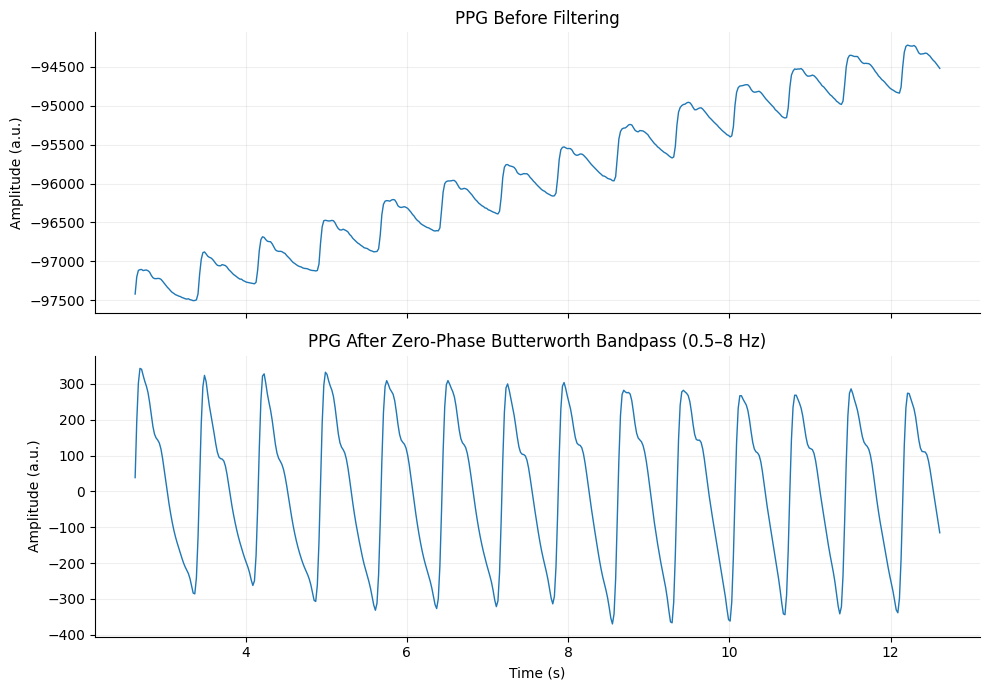

In [23]:
fig, axes = plt.subplots(
    2,
    1,
    figsize=(10, 7),
    sharex=True,
)

# Before filtering
axes[0].plot(
    time_plot,
    raw_plot,
    linewidth=1.0,
)

axes[0].set_title("PPG Before Filtering")
axes[0].set_ylabel("Amplitude (a.u.)")

# After filtering
axes[1].plot(
    time_plot,
    filtered_plot,
    linewidth=1.0,
)

axes[1].set_title(
    "PPG After Zero-Phase Butterworth Bandpass "
    "(0.5–8 Hz)"
)
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Amplitude (a.u.)")

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

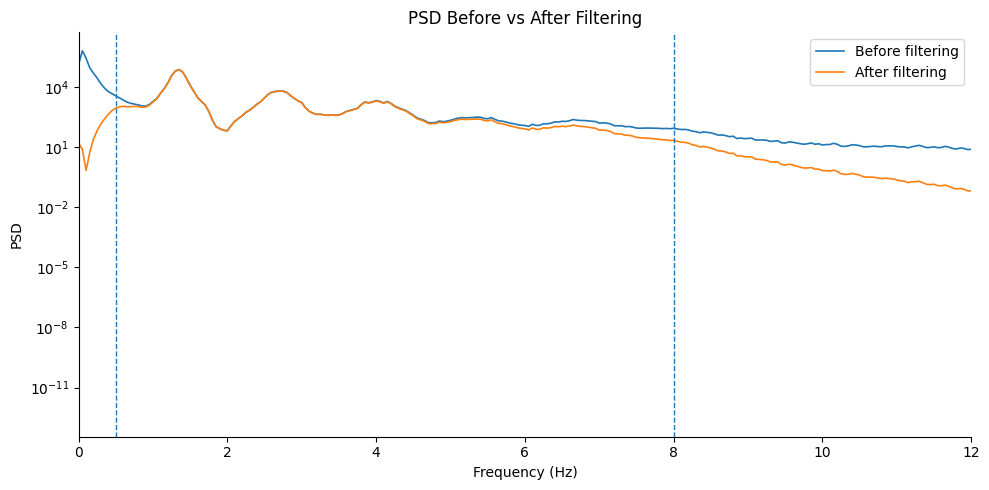

In [24]:
from scipy.signal import welch

# Welch PSD
nperseg = min(int(fs * 20), len(ppg_inverted))

freq_before, psd_before = welch(
    ppg_inverted,
    fs=fs,
    nperseg=nperseg,
)

freq_after, psd_after = welch(
    ppg_filtered,
    fs=fs,
    nperseg=nperseg,
)

fig, ax = plt.subplots(figsize=(10, 5))

ax.semilogy(
    freq_before,
    psd_before,
    label="Before filtering",
    linewidth=1.2,
)

ax.semilogy(
    freq_after,
    psd_after,
    label="After filtering",
    linewidth=1.2,
)

ax.axvline(0.5, linestyle="--", linewidth=1)
ax.axvline(8.0, linestyle="--", linewidth=1)

ax.set_xlim(0, min(12, fs / 2))
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("PSD")
ax.set_title("PSD Before vs After Filtering")
ax.legend()

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [25]:
import numpy as np


def band_power(freq, psd, low, high):
    """Integrate PSD within a frequency band."""
    mask = (freq >= low) & (freq <= high)

    if mask.sum() < 2:
        return np.nan

    return np.trapezoid(psd[mask], freq[mask])


LOWCUT = 0.5
HIGHCUT = 8.0
NYQUIST = fs / 2.0

# Before filtering
before_low = band_power(
    freq_before,
    psd_before,
    0.0,
    LOWCUT,
)

before_in = band_power(
    freq_before,
    psd_before,
    LOWCUT,
    HIGHCUT,
)

before_high = (
    band_power(freq_before, psd_before, HIGHCUT, NYQUIST)
    if HIGHCUT < NYQUIST
    else 0.0
)

# After filtering
after_low = band_power(
    freq_after,
    psd_after,
    0.0,
    LOWCUT,
)

after_in = band_power(
    freq_after,
    psd_after,
    LOWCUT,
    HIGHCUT,
)

after_high = (
    band_power(freq_after, psd_after, HIGHCUT, NYQUIST)
    if HIGHCUT < NYQUIST
    else 0.0
)

# Ratios
in_band_retention = after_in / before_in

low_band_ratio = after_low / before_low
high_band_ratio = (
    after_high / before_high
    if before_high > 0
    else np.nan
)

print(f"In-band power retention : {in_band_retention:.4f}")
print(f"Low-frequency ratio     : {low_band_ratio:.4f}")
print(f"High-frequency ratio    : {high_band_ratio:.4f}")

In-band power retention : 0.9675
Low-frequency ratio     : 0.0011
High-frequency ratio    : 0.1060


In [26]:
from scipy.signal import find_peaks

# Minimum pulse distance corresponding to ~200 bpm
min_peak_distance = int(fs * 0.30)

# Adaptive prominence for each signal
prominence_before = 0.25 * np.std(ppg_inverted)
prominence_after = 0.25 * np.std(ppg_filtered)

peaks_before, _ = find_peaks(
    ppg_inverted,
    distance=min_peak_distance,
    prominence=prominence_before,
)

peaks_after, _ = find_peaks(
    ppg_filtered,
    distance=min_peak_distance,
    prominence=prominence_after,
)

print(f"Peaks before filtering: {len(peaks_before)}")
print(f"Peaks after filtering : {len(peaks_after)}")

peak_count_difference = len(peaks_after) - len(peaks_before)

peak_count_change_pct = (
    peak_count_difference / len(peaks_before) * 100
    if len(peaks_before) > 0
    else np.nan
)

print(f"Peak-count difference  : {peak_count_difference:+d}")
print(f"Peak-count change       : {peak_count_change_pct:.2f}%")

Peaks before filtering: 2613
Peaks after filtering : 3216
Peak-count difference  : +603
Peak-count change       : 23.08%


In [27]:
peak_times_before = time[peaks_before]
peak_times_after = time[peaks_after]

MATCH_TOLERANCE_S = 0.10

timing_differences = []

for peak_time in peak_times_after:
    nearest_index = np.argmin(
        np.abs(peak_times_before - peak_time)
    )

    difference = (
        peak_time - peak_times_before[nearest_index]
    )

    if abs(difference) <= MATCH_TOLERANCE_S:
        timing_differences.append(difference)

timing_differences = np.asarray(timing_differences)

matched_peaks = len(timing_differences)

match_rate = (
    matched_peaks / len(peaks_after) * 100
    if len(peaks_after) > 0
    else np.nan
)

median_shift_ms = (
    np.median(np.abs(timing_differences)) * 1000
    if matched_peaks > 0
    else np.nan
)

max_shift_ms = (
    np.max(np.abs(timing_differences)) * 1000
    if matched_peaks > 0
    else np.nan
)

print(f"Matched peaks          : {matched_peaks}")
print(f"Peak match rate        : {match_rate:.2f}%")
print(f"Median timing shift    : {median_shift_ms:.2f} ms")
print(f"Maximum timing shift   : {max_shift_ms:.2f} ms")

Matched peaks          : 2585
Peak match rate        : 80.38%
Median timing shift    : 0.00 ms
Maximum timing shift   : 100.00 ms


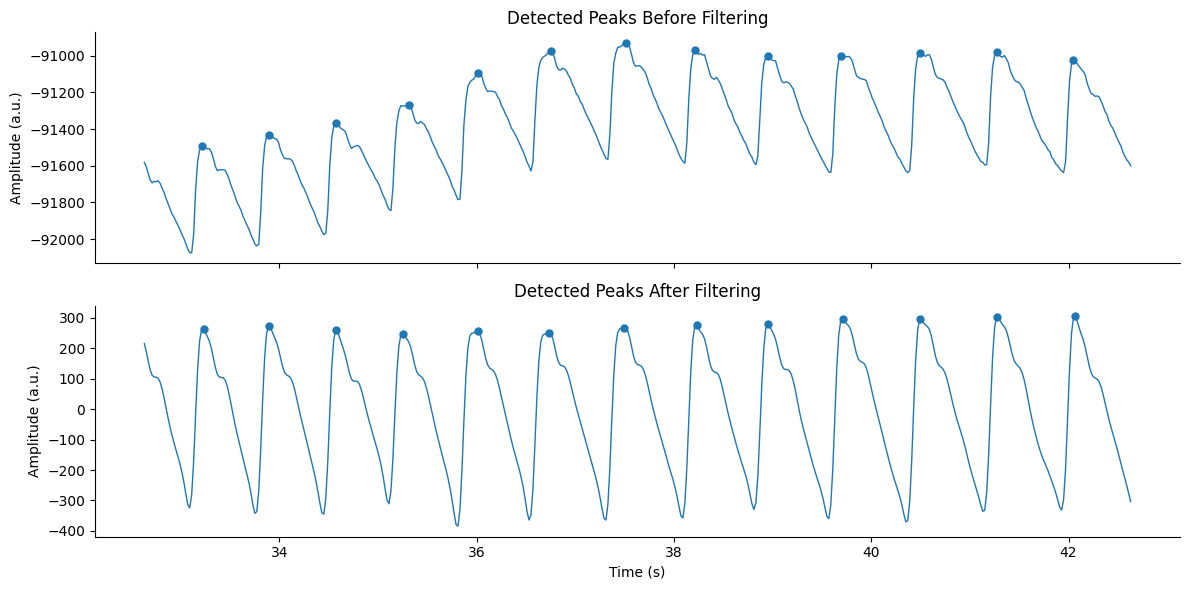

In [28]:
start_s = time[0] + 30
end_s = start_s + 10

signal_mask = (time >= start_s) & (time <= end_s)

before_peak_mask = (
    (peak_times_before >= start_s)
    & (peak_times_before <= end_s)
)

after_peak_mask = (
    (peak_times_after >= start_s)
    & (peak_times_after <= end_s)
)

fig, axes = plt.subplots(
    2,
    1,
    figsize=(12, 6),
    sharex=True,
)

# Before
axes[0].plot(
    time[signal_mask],
    ppg_inverted[signal_mask],
    linewidth=1,
)

before_indices = peaks_before[before_peak_mask]

axes[0].scatter(
    time[before_indices],
    ppg_inverted[before_indices],
    s=25,
    zorder=3,
)

axes[0].set_ylabel("Amplitude (a.u.)")
axes[0].set_title("Detected Peaks Before Filtering")

# After
axes[1].plot(
    time[signal_mask],
    ppg_filtered[signal_mask],
    linewidth=1,
)

after_indices = peaks_after[after_peak_mask]

axes[1].scatter(
    time[after_indices],
    ppg_filtered[after_indices],
    s=25,
    zorder=3,
)

axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Amplitude (a.u.)")
axes[1].set_title("Detected Peaks After Filtering")

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

# Filter Evaluation — Sample 1

## Kết quả

- **In-band power retention:** `96.75%`
- **Low-frequency ratio:** `0.0011`
- **High-frequency ratio:** `0.1060`

- **Peaks before filtering:** `2613`
- **Peaks after filtering:** `3216`
- **Peak-count change:** `+23.08%`

- **Matched peaks:** `2585`
- **Peak match rate:** `80.38%`
- **Median timing shift:** `0 ms`
- **Maximum timing shift:** `100 ms`

## Đánh giá sơ bộ

### Frequency domain

Bộ lọc hoạt động tốt về mặt phổ:

- giữ lại khoảng `96.75%` năng lượng trong dải `0.5–8 Hz`;
- loại gần như toàn bộ thành phần `< 0.5 Hz`;
- giảm mạnh thành phần `> 8 Hz`.

Điều này cho thấy bandpass đang loại baseline drift và high-frequency noise mà vẫn bảo toàn phần lớn năng lượng trong passband.

### Peak preservation

Kết quả peak detection cần được chú ý:

- số peak tăng `23.08%` sau filtering;
- chỉ khoảng `80.38%` peak sau filter match với peak trước filter;
- các peak match có median timing shift bằng `0 ms`.

Timing của các peak được bảo toàn tốt, nhưng số peak tăng khá lớn. Điều này có thể do filter làm pulse rõ hơn, nhưng cũng có thể tạo thêm local maxima được peak detector nhận diện.

## Kết luận

Bộ lọc `0.5–8 Hz`, Butterworth order 2, zero-phase cho kết quả **tốt về bảo toàn phổ**, nhưng **chưa thể kết luận hoàn toàn phù hợp dựa trên peak count**.

Trước khi freeze filter cần:

1. kiểm tra peak-count behavior trên nhiều session;
2. trực quan hóa các peak được thêm sau filtering;
3. không dùng peak detector hiện tại như tiêu chuẩn cuối cùng cho PPI;
4. đánh giá filter trên toàn dataset trước khi chốt tham số.